Script based on https://bookdown.org/amesoudi/ABMtutorial_bookdown/model11.html

With added comments and some modifications by OM & AB

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(37)

## A. Building the model

### A0. Initialise the population

We represent the population as a matrix of shape *(n, N)*, where:
- **N**: the number of groups (columns)
- **n**: the number of agents per group (rows)

Each cell holds a strategy label: **C** (Cooperator), **D** (Defector), or **P** (Punisher).

For exploration purpose, we will initalize the agents randomly. However, we will also prepare for the real model later on with the initial condition used in the full simulation places all Punishers in group 1, all Cooperators in the last group, and Defectors everywhere else. Here we use a small hand-crafted example to illustrate each stage.

In [2]:
def initialise_agents(n, N, random=False):
    """A0. Create the agent matrix with the standard initial conditions.
    
    - If random=False (default): group 0 = all P, group N-1 = all C, others = all D
    - If random=True: each agent is assigned C, D, or P with equal probability (1/3 each)

    Parameters
    ----------
    n      (int) : number of agents per group
    N      (int) : number of groups
    random (bool): if True, assign strategies randomly; default is False

    Returns
    -------
    agent: np.ndarray of shape (n, N)
    """
    agent = np.empty((n, N), dtype=str)

    if random:
        # Each agent independently draws from {C, D, P} with equal probability
        agent = np.random.choice(["C", "D", "P"], size=(n, N))
    else:
        # Standard initial conditions from Boyd et al. 2003
        agent[:, 0] = "P"
        agent[:, 1:] = "D"
    return agent

Let's try it with a small example: *n* = 4 agents, *N* = 4 groups.

In [3]:
n = 4  # agents per group
N = 4  # number of groups

agents_matrix = initialise_agents(n, N, random=True)
agents_matrix

array([['C', 'C', 'D', 'P'],
       ['P', 'P', 'D', 'C'],
       ['D', 'P', 'C', 'C'],
       ['P', 'C', 'C', 'P']], dtype='<U1')

### A1. Cooperation -> the good guys pay a cost

Every agent starts with a baseline payoff of **1**. This arbitrary floor prevents negative payoffs from breaking the social-learning step later.

At this stage, Cooperators (C) and Punishers (P) contribute to their group's public good with probability **1 − e**, and defect by mistake with probability **e**. The parameter **e** represents cooperation errors: a C or P agent accidentally defects when they intended to cooperate. We set **e = 0** for now to keep the output clean, but you can increase it to explore its effect. In the full simulation below we use **e = 0.01**.

Contributing agents pay a cost **c**, making cooperation altruistic.

Defectors (D) always defect and bear no cost.

In [4]:
def initialise_payoffs(n, N):
    """A1a. Create a payoff matrix filled with the baseline payoff of 1.

    Parameters
    ----------
    n (int): number of agents per group
    N (int): number of groups

    Returns
    -------
    payoff: np.ndarray of shape (n, N)
    """
    return np.ones((n, N), dtype=float)


def apply_cooperation_costs(agent, payoff, c, e=0):
    """A1b. Reduce the payoff of every contributor (C or P) by c.

    Contributors are C or P agents who cooperate with probability 1-e.
    The parameter e represents cooperation errors: a C or P agent 
    accidentally defects with probability e.

    Parameters
    ----------
    agent (np.ndarray of shape (n, N)) : strategy matrix
    payoff (np.ndarray of shape (n, N)): payoff matrix
    c (float)                          : cost of cooperation
    e (float)                          : cooperation error rate

    Returns
    -------
    payoff (np.ndarray)      : updated payoff matrix
    contributors (np.ndarray): boolean mask of contributing agents
    """
    # Random draw to determine whether each C/P agent cooperates this round
    contribute = np.random.uniform(size=agent.shape)

    # Contributors are C or P agents who clear the 1-e threshold
    contributors = ((agent == "C") | (agent == "P")) & (contribute > e)

    payoff[contributors] -= c
    return payoff, contribute

In [5]:
c = 0.2  # cost of cooperation

payoff = initialise_payoffs(n, N)
payoff, contribute = apply_cooperation_costs(agents_matrix, payoff, c)

print("\nPayoff after cooperation costs:")
print(payoff)


Payoff after cooperation costs:
[[0.8 0.8 1.  0.8]
 [0.8 0.8 1.  0.8]
 [1.  0.8 0.8 0.8]
 [0.8 0.8 0.8 0.8]]


### A2. Punishment -> Punishers punish Defectors

Punishers (P) punish every agent in their group who defected in stage 1: actual Defectors (D), but also any C or P agent who defected by mistake (with probability **e**). This is why punishment operates on `defections` rather than just on `agent == "D"`.
- **k**: the cost to punisher
- **p**: the cost to punished

The model (following Boyd et al. 2003) assumes **k < p**: punishment is costly for the punisher but even more costly for the punished.

Punishment only happens in groups that contain at least one P. Within those groups, each Punisher:
1. Pays **k/n** for every defector in its group (excluding itself).
2. Inflicts a cost of **p/n** on each of those defectors.

Costs are divided by *n* (group size) to keep them independent of group size.

In [6]:
def apply_punishment(agent, payoff, contribute, p, k, e = 0):
    """A2. Apply punishment costs within groups that contain at least one Punisher.

    For each Punisher i in group j:
      - Punisher's payoff is reduced by (k/n) * number_of_defectors_in_group
      - Each defector's payoff in the group is reduced by p/n

    Parameters
    ----------
    agent  (np.ndarray of shape (n, N)): strategy matrix
    payoff (np.ndarray of shape (n, N)): payoff matrix (modified in-place)
    p (float)                          : cost inflicted on each defector
    k (float)                          : cost paid by each punisher per defector
    e (float)                          : cooperation error rate

    Returns
    -------
    payoff (np.ndarray): updated payoff matrix
    """
    n = agent.shape[0]

    # Identify groups that contain at least one punisher
    groups_with_punishers = np.unique(np.where(agent == "P")[1])

    # Boolean mask: True where agent is a Defector
    defections = (agent == "D") | (((agent == "C") | (agent == "P")) & (contribute <= e))

    for j in groups_with_punishers:
        for i in range(n):
            if agent[i, j] == "P":

                # Boolean mask: all agents in this group except agent i
                other_rows = np.arange(n) != i

                # Number of defectors in the group, excluding the punisher itself
                n_defectors = np.sum(defections[other_rows, j])

                # Punisher pays k/n per defector
                payoff[i, j] -= n_defectors * k / n

                # Indices of those defectors
                defector_indices = np.where(other_rows & defections[:, j])[0]

                # Each defector receives a penalty of p/n
                payoff[defector_indices, j] -= p / n

    return payoff

In [7]:
p = 0.8
k = 0.8

payoff = apply_punishment(agents_matrix, payoff, contribute, p, k)

print("Agent matrix:")
print(agents_matrix)
print("\nPayoff after punishment:")
print(payoff)

Agent matrix:
[['C' 'C' 'D' 'P']
 ['P' 'P' 'D' 'C']
 ['D' 'P' 'C' 'C']
 ['P' 'C' 'C' 'P']]

Payoff after punishment:
[[0.8 0.8 1.  0.8]
 [0.6 0.8 1.  0.8]
 [0.6 0.8 0.8 0.8]
 [0.6 0.8 0.8 0.8]]


### A3. Payoff-biased social learning

Agents update their strategy by copying a *demonstrator* chosen proportionally to payoff:

- With probability **1 − m**, an agent picks a demonstrator from its **own group** (excluding itself).
- With probability **m**, it picks a demonstrator from a **different group** (any agent, any other group).

Once a demonstrator is chosen, the probability of copying their strategy is:

$$W = \frac{\text{payoff}_{\text{dem}}}{\text{payoff}_{\text{dem}} + \text{payoff}_{\text{agent}}}$$

This means higher-payoff demonstrators are more likely to be copied. It is a simple form of success-biased transmission.

**Important:** we copy from `previous_agent` (a snapshot taken before the learning phase begins) to prevent an agent from copying another agent who has *already* updated their strategy in the same time step. Without this, early-updated agents would have an unfair influence.

In [8]:
def social_learning(agent, payoff, m):
    """A3. Payoff-biased social learning across and within groups.

    Each agent selects a demonstrator (within-group with prob 1-m,
    between-group with prob m) and copies their strategy with
    probability W = payoff_dem / (payoff_dem + payoff_agent).

    Parameters
    ----------
    agent (np.ndarray of shape (n, N)) : strategy matrix
    payoff (np.ndarray of shape (n, N)): payoff matrix
    m (float): probability of choosing a between-group demonstrator

    Returns
    -------
    agent (np.ndarray): updated strategy matrix
    """
    n, N = agent.shape

    # Snapshot of strategies before learning begins, to avoid overlap:
    # an agent updated early in the loop must not influence agents updated later
    previous_agent = agent.copy()

    for j in range(N):
        for i in range(n):

            # --- Select demonstrator ---
            if np.random.uniform() > m:
                # Within-group: pick any agent in the same group, excluding self
                same_group_others = np.arange(n)[np.arange(n) != i]
                dem_row = np.random.choice(same_group_others)
                dem_col = j
            else:
                # Between-group: pick any agent from a different group
                other_groups = np.arange(N)[np.arange(N) != j]
                dem_row = np.random.choice(np.arange(n))
                dem_col = np.random.choice(other_groups)

            # --- Compute copying probability W ---
            dem_payoff   = payoff[dem_row, dem_col]
            agent_payoff = payoff[i, j]
            W = dem_payoff / (dem_payoff + agent_payoff)

            # --- Copy demonstrator's strategy with probability W ---
            if np.random.uniform() < W:
                agent[i, j] = previous_agent[dem_row, dem_col]

    return agent

In [9]:
m = 0.01  # rate of between-group mixing

agents_matrix = social_learning(agents_matrix, payoff, m)

print("Agent matrix after social learning:")
print(agents_matrix)

Agent matrix after social learning:
[['C' 'P' 'D' 'C']
 ['P' 'P' 'D' 'C']
 ['P' 'P' 'D' 'C']
 ['P' 'C' 'C' 'C']]


### A4. Group selection -> groups compete

At this stage, groups can fight each other. The frequency of conflict is governed by **ε**:

1. We first randomly pair up all *N* groups into *N/2* potential contests.
2. Each contest is kept with probability **ε** ; so when ε = 0, no fighting occurs at all.
3. For each surviving contest, the outcome is determined by the proportion of Defectors in each group. More defectors → weaker group (following Boyd et al. 2003):

$$d = 0.5 + \frac{d_2 - d_1}{2}$$

where $d_1$ and $d_2$ are the defector proportions in group 1 and group 2 respectively. $d$ is the probability that group 1 wins.

4. The losing group is **completely replaced** by the winning group.

> **Note:** complete replacement is a strong assumption, unlikely in reality, but it simplifies the model considerably.

In [10]:
def group_selection(agent, contribute, epsilon, e=0):
    """A4. Inter-group conflict and group selection.

    Groups are randomly paired. Each contest is kept with probability epsilon.
    The group with fewer defectors is more likely to win and replace the loser.

    Parameters
    ----------
    agent (np.ndarray of shape (n, N)): strategy matrix
    epsilon (float): probability that each potential contest actually takes place

    Returns
    -------
    agent (np.ndarray): updated strategy matrix
    """
    n, N = agent.shape

    # --- Create random pairings of all N groups ---
    shuffled = np.random.permutation(N)
    contests = pd.DataFrame(shuffled.reshape(N // 2, 2), columns=["group1", "group2"])

    # --- Keep only a fraction of contests, determined by epsilon ---
    contests = contests[np.random.uniform(size=N // 2) < epsilon].reset_index(drop=True)

    # --- Recompute defectors at this point in time ---
    defections = (agent == "D") | (((agent == "C") | (agent == "P")) & (contribute <= e))

    # --- Only run if at least one contest survived the epsilon filter ---
    if len(contests) > 0:

        for i in range(len(contests)):

            group1 = int(contests.loc[i, "group1"])
            group2 = int(contests.loc[i, "group2"])

            # Proportion of defectors in each competing group
            d1 = np.sum(defections[:, group1]) / n
            d2 = np.sum(defections[:, group2]) / n

            # Probability that group1 wins (Boyd et al. 2003)
            # More defectors in group2 → higher chance group1 wins
            d = 0.5 + (d2 - d1) / 2

            if np.random.uniform() < d:
                # Group 1 wins: group 2 is fully replaced by group 1
                agent[:, group2] = agent[:, group1]
            else:
                # Group 2 wins: group 1 is fully replaced by group 2
                agent[:, group1] = agent[:, group2]

    return agent

In [11]:
epsilon = 0.5  # frequency of conflict

agents_matrix = group_selection(agents_matrix, contribute, epsilon)

print("Agent matrix after group selection:")
print(agents_matrix)

Agent matrix after group selection:
[['C' 'D' 'D' 'C']
 ['P' 'D' 'D' 'C']
 ['P' 'D' 'D' 'C']
 ['P' 'C' 'C' 'C']]


### A5. Mutation

Stage 5 is mutation. There is a probability **μ** that each agent will mutate into one of the other two types (i.e. C into D or P; P into C or D; and D into C or P). This keeps a small, constant supply of new variation coming into the population so that we are not entirely reliant on the starting conditions.


We create a matrix of random probabilities *mutate*, one per agent, and if the probability for an agent is less than **μ** (mu) then we mutate into one of the other two types at random. 


Here, **μ = 0.5**, which is an unrealistically high rate for demonstration purposes. In the full simulation below we use **μ = 0.01**. In the resulting *agent* matrix, roughly half of the agents should have switched behaviours.

In [ ]:
def mutation(agent, mu=0.5):
    """A.5 Mutation
    Mutate agent strategies with probability mu.

    Parameters
    ----------
    agent (np.ndarray of shape (n, N)): strategy matrix
    mu (float): mutation probability

    Returns
    -------
    agent (np.ndarray): updated strategy matrix
    """
    n, N = agent.shape

    # Flattened mutation draws
    mutate = np.random.uniform(size=n * N).reshape(n, N)

    # Snapshot to avoid overlap
    previous_agent = agent.copy()

    # --- Mutate D agents → {P, C} ---
    mask_D = (mutate < mu) & (previous_agent == "D")
    agent[mask_D] = np.random.choice(["P", "C"], size=mask_D.sum(), replace=True)

    # --- Mutate C agents → {P, D} ---
    mask_C = (mutate < mu) & (previous_agent == "C")
    agent[mask_C] = np.random.choice(["P", "D"], size=mask_C.sum(), replace=True)

    # --- Mutate P agents → {D, C} ---
    mask_P = (mutate < mu) & (previous_agent == "P")
    agent[mask_P] = np.random.choice(["D", "C"], size=mask_P.sum(), replace=True)

    return agent


## B. Putting it all together

We now assemble all four stages into a single simulation function. At each time step *t*:

1. **Cooperation**: contributors (C and P) pay cost *c*
2. **Punishment**: punishers pay *k* and inflict *p* on defectors
3. **Social learning**: agents copy higher-payoff demonstrators
4. **Group selection**: groups compete, losers are replaced

We track two quantities over time:
- **PandC**: frequency of cooperators + punishers (all contributors)
- **P**: frequency of punishers alone

Parameter reference values (from Boyd et al. 2003 / Mesoudi's tutorial):

| Parameter | Description                        | Default|
|-----------|------------------------------------|--------|
| N         | Number of groups                   | 128    |
| n         | Agents per group                   | 4     |
| t_max     | Number of time steps               | 1000   |
| c         | Cost of cooperation                | 0.2    |
| m         | Rate of between-group mixing       | 0.01   |
| e         | Cooperation error rate             | 0.02   |
| p         | Punishment cost to defector        | 0.8    |
| k         | Punishment cost to punisher        | 0.2    |
| mu        | Mutation rate                      | 0.01   |
| epsilon   | Frequency of inter-group conflict  | 0.015  |

In [18]:
def cooperation(N=128,
                n=4,
                t_max=1000,
                c=0.2,
                m=0.01,
                e=0.02,
                p=0.8,
                k=0.2,
                mu=0.01,
                epsilon=0.015,
                show_plot=True):

    """Run the cultural group selection simulation (Boyd et al. 2003).

    At each time step:
      1. Contributors (C, P) pay cooperation cost c
      2. Punishers pay k per defector and inflict cost p on each defector
      3. Agents copy higher-payoff demonstrators (within- or between-group)
      4. Groups compete; the losing group is fully replaced by the winner

    Parameters
    ----------
    N (int)         : number of groups
    n (int)         : agents per group
    t_max (int)     : number of time steps
    c (float)       : cost of cooperation
    m (float)       : between-group mixing rate
    e (float)       : cooperation error rate
    p (float)       : punishment cost inflicted on each defector
    k (float)       : punishment cost paid by each punisher per defector
    mu (float)      : mutation rate
    epsilon (float) : frequency of inter-group conflict
    show_plot (bool): if True, plot cooperation and punishment frequencies

    Returns
    -------
    dict with keys:
      'agent'     : final agent matrix (np.ndarray)
      'output'    : pd.DataFrame with columns PandC and P over time
      'mean_coop' : mean cooperation frequency over the last 50% of time steps
    """

    # --- Initialise agent matrix and output tracker ---
    agent = initialise_agents(n, N)
    output = pd.DataFrame({"PandC": np.full(t_max, np.nan),
                           "P":     np.full(t_max, np.nan)})

    # Record frequencies at t = 0 (initial state)
    output.loc[0, "PandC"] = np.sum((agent == "C") | (agent == "P")) / (N * n)
    output.loc[0, "P"]     = np.sum(agent == "P") / (N * n)

    for t in range(1, t_max):

        # 1. Cooperation
        payoff = initialise_payoffs(n, N)
        payoff, contribute = apply_cooperation_costs(agent, payoff, c, e)

        # 2. Punishment
        payoff = apply_punishment(agent, payoff, contribute, p, k, e)

        # 3. Social learning
        agent = social_learning(agent, payoff, m)

        # 4. Group selection
        agent = group_selection(agent, contribute, epsilon, e)

        # 5. Mutation
        agent = mutation(agent, mu)

        # Record cooperation and punishment frequencies for this time step
        output.loc[t, "PandC"] = np.sum((agent == "C") | (agent == "P")) / (N * n)
        output.loc[t, "P"]     = np.sum(agent == "P") / (N * n)

    # --- Optional plot ---
    if show_plot:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(range(t_max), output["PandC"], linestyle="-",      label="C and P (all contributors)")
        ax.plot(range(t_max), output["P"],     linestyle="dotted", label="P only (punishers)")
        ax.set_ylim(0, 1)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Frequency")
        ax.set_title("Cultural group selection - Boyd et al. 2003")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Mean cooperation over the second half of the simulation
    mean_coop = output["PandC"].iloc[t_max // 2:].mean()

    return {"agent": agent, "output": output, "mean_coop": mean_coop}

Let's run the simulation with the default parameters and look at the results.

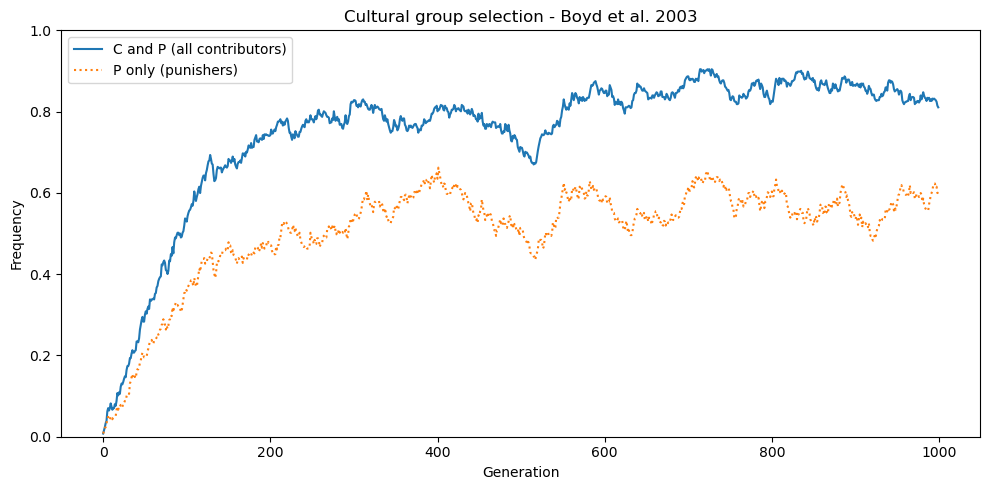

Mean cooperation (last 50% of time steps): 0.840


In [17]:
simulations = cooperation(n = 4)

print(f"Mean cooperation (last 50% of time steps): {simulations['mean_coop']:.3f}")

# C. Exercices

## C1. Impact of punishment

Is punishment needed when group mixing does not occur? Why?

Test your answer


**Note:** for this exercice, put n (number of agents) at 32.

**Tips:** mix both the mixing (m) and the punishment variable (p & k) in this way:
| Simulation | Mixing | Punishment |
|--|--|---|
| A | x          | x           |
| B          | o          | x           |
| C | x | o |
| D | o | o |

## C2. Parameter testing

Pick three parameters that, in your view, seem indispensable to the evolution of cooperation in this model. 


Why does it seem indispensable? And is it?

## C3. Varying cost of punishment

The reason why cooperation-with-punishment evolves more easily than cooperation tout court is, Boyd et al. argue, because the costs of cooperation are fixed, while the costs of punishing vary with the number of defectors.


Test this hypothesis.

Note: here, you have to modify the either cooperation cost or punishment cost are computed. Punishment cost are varying in the model, so you have to change that to fix it. Inversely, cooperation cost are fixed, so you have to change that to an equation (based for example on the number of cooperator).